# 【baidu/Unlimited-OCR】OCR推理服务
====

> **Unlimited-OCR — One-shot Long-horizon Document Parsing**：百度开源的端到端 OCR 模型，
> 支持单张图像和 PDF 文档的高精度文字检测与识别。
> 基于 DeepSeek-V2 MoE 架构 + 双视觉编码器（SAM-ViT-B + CLIP-L-14），
> 采用 Reference Sliding Window Attention（R-SWA）保持常量 KV 缓存。
> MIT 开源许可证，可免费商用。
> S2.gpu.large（24GB）单卡即可运行。

## 一、项目简介

### 1.1 官方项目简介

Unlimited-OCR 是百度推出的端到端多页文档解析 OCR 模型。与传统的逐行 OCR 不同，
该模型能够在单次前向传播中解析数十页文档，保持常量 KV 缓存大小，
不会因文档长度增加而导致推理速度下降。

| 属性 | 值 |
|------|-----|
| 参数量 | 3.3B BF16（DeepSeek-V2 MoE 架构） |
| 上下文长度 | 32K tokens |
| 架构 | UnlimitedOCRForCausalLM（trust_remote_code） |
| 视觉编码器 | SAM-ViT-B + CLIP-L-14（双编码器） |
| 注意力机制 | R-SWA（Reference Sliding Window Attention） |
| 推理模式 | gundam（640px+动态裁剪）/ base（1024px 完整分辨率） |
| 输入格式 | 单图（PNG/JPG） / PDF 文档（自动转图） |
| 输出格式 | 结构化 HTML，含 `<|det|>` 检测框 + 文字内容 |
| 许可证 | MIT（可商用） |
| 显存需求 | ~6GB（推理），~16GB 推荐 |

### 1.2 本项目简介

本项目在趋动云平台部署 baidu/Unlimited-OCR 推理服务，提供 Gradio WebUI 图形界面。
支持单图片 OCR 和 PDF 文档 OCR 两种模式，模型懒加载，首次推理约 12 分钟后即可使用。

| 属性 | 值 |
|------|-----|
| 推理框架 | PyTorch 2.10.0 + Transformers 4.57.1 |
| Web UI | Gradio 5.x |
| Python | 3.10 |
| CUDA | 12.4 |
| 模型格式 | BF16 Safetensors（1 分片，~6.6GB） |
| PDF 支持 | PyMuPDF 1.27.2 转换 → 逐页 OCR |
| 每批 PDF 页数 | 50 页 / 批 |

### 1.3 关键架构特点

- **R-SWA（Reference Sliding Window Attention）**：创新注意力机制，KV 缓存大小恒定
- **双视觉编码器**：SAM-ViT-B 用于布局感知 + CLIP-L-14 用于语义理解
- **两种推理模式**：gundam（640px，动态裁剪，密集文字）和 base（1024px，完整分辨率）
- **PDF 自动处理**：PDF 文件自动转图片 → 分批推理 → 合并结果
- **结构化输出**：以 `<|det|>` 标签输出检测框坐标 + 文字内容，保留原始布局

## 二、官方链接

| 类别 | 链接 |
|------|------|
| 🤗 HuggingFace | https://huggingface.co/baidu/Unlimited-OCR |
| 📄 技术博客 | https://baidu.com（搜索「Unlimited-OCR」） |
| 🐙 GitHub | https://github.com/baidu/Unlimited-OCR |
| 🇨🇳 hf-mirror 镜像 | https://hf-mirror.com/baidu/Unlimited-OCR |

## 三、算力推荐

| 配置 | 推荐 GPU | 显存要求 | 说明 |
|------|---------|:-------:|------|
| **最低配置** | T4 / A10 | ≥ 6 GB | 可加载模型，推荐 gundam 模式，避免大图 OOM |
| **推荐配置** | S2.gpu.large（24GB） | ≥ 16 GB | **推荐**，两种模式均可流畅运行 ~142 char/s |
| **批量 PDF** | S2.gpu.large（24GB） | ≥ 24 GB | 一次处理多页 PDF，建议 50 页/批 |

> ⚠️ 3.3B BF16 权重约 6.6GB，实际推理时 base 模式（1024px）需要更多中间显存。
> 推荐使用 S2.gpu.large（24GB）规格以获得最佳体验。

## 四、推理服务配置

| 配置项 | 值 |
|--------|-----|
| 镜像 | 自建 Python 3.10 + CUDA 12.4 镜像 |
| 模型挂载 | `/gemini/pretrain`（包含模型权重 ~6.6GB） |
| 代码目录 | `/gemini/code/`（上传 `app.py`、`start.sh`） |
| 启动命令 | `bash /gemini/code/start.sh` |
| 服务端口 | **7860**（必须开放此端口） |
| 访问路由 | `/` -> Gradio WebUI |
| 推理引擎 | transformers 4.57.1 + PyTorch 2.10.0 |
| 环境变量 | `MODEL_PATH=/gemini/code/models`、`HF_ENDPOINT=https://hf-mirror.com` |

## 五、使用说明

### 5.1 一键启动

必须先开放 **7860** 端口，一键启动如下：

In [ ]:
! bash /gemini/code/start.sh

或直接启动 Python 脚本（不安装依赖时）：

In [ ]:
! cd /gemini/code && python app.py

### 5.3 WebUI 界面展示

#### 单图OCR界面

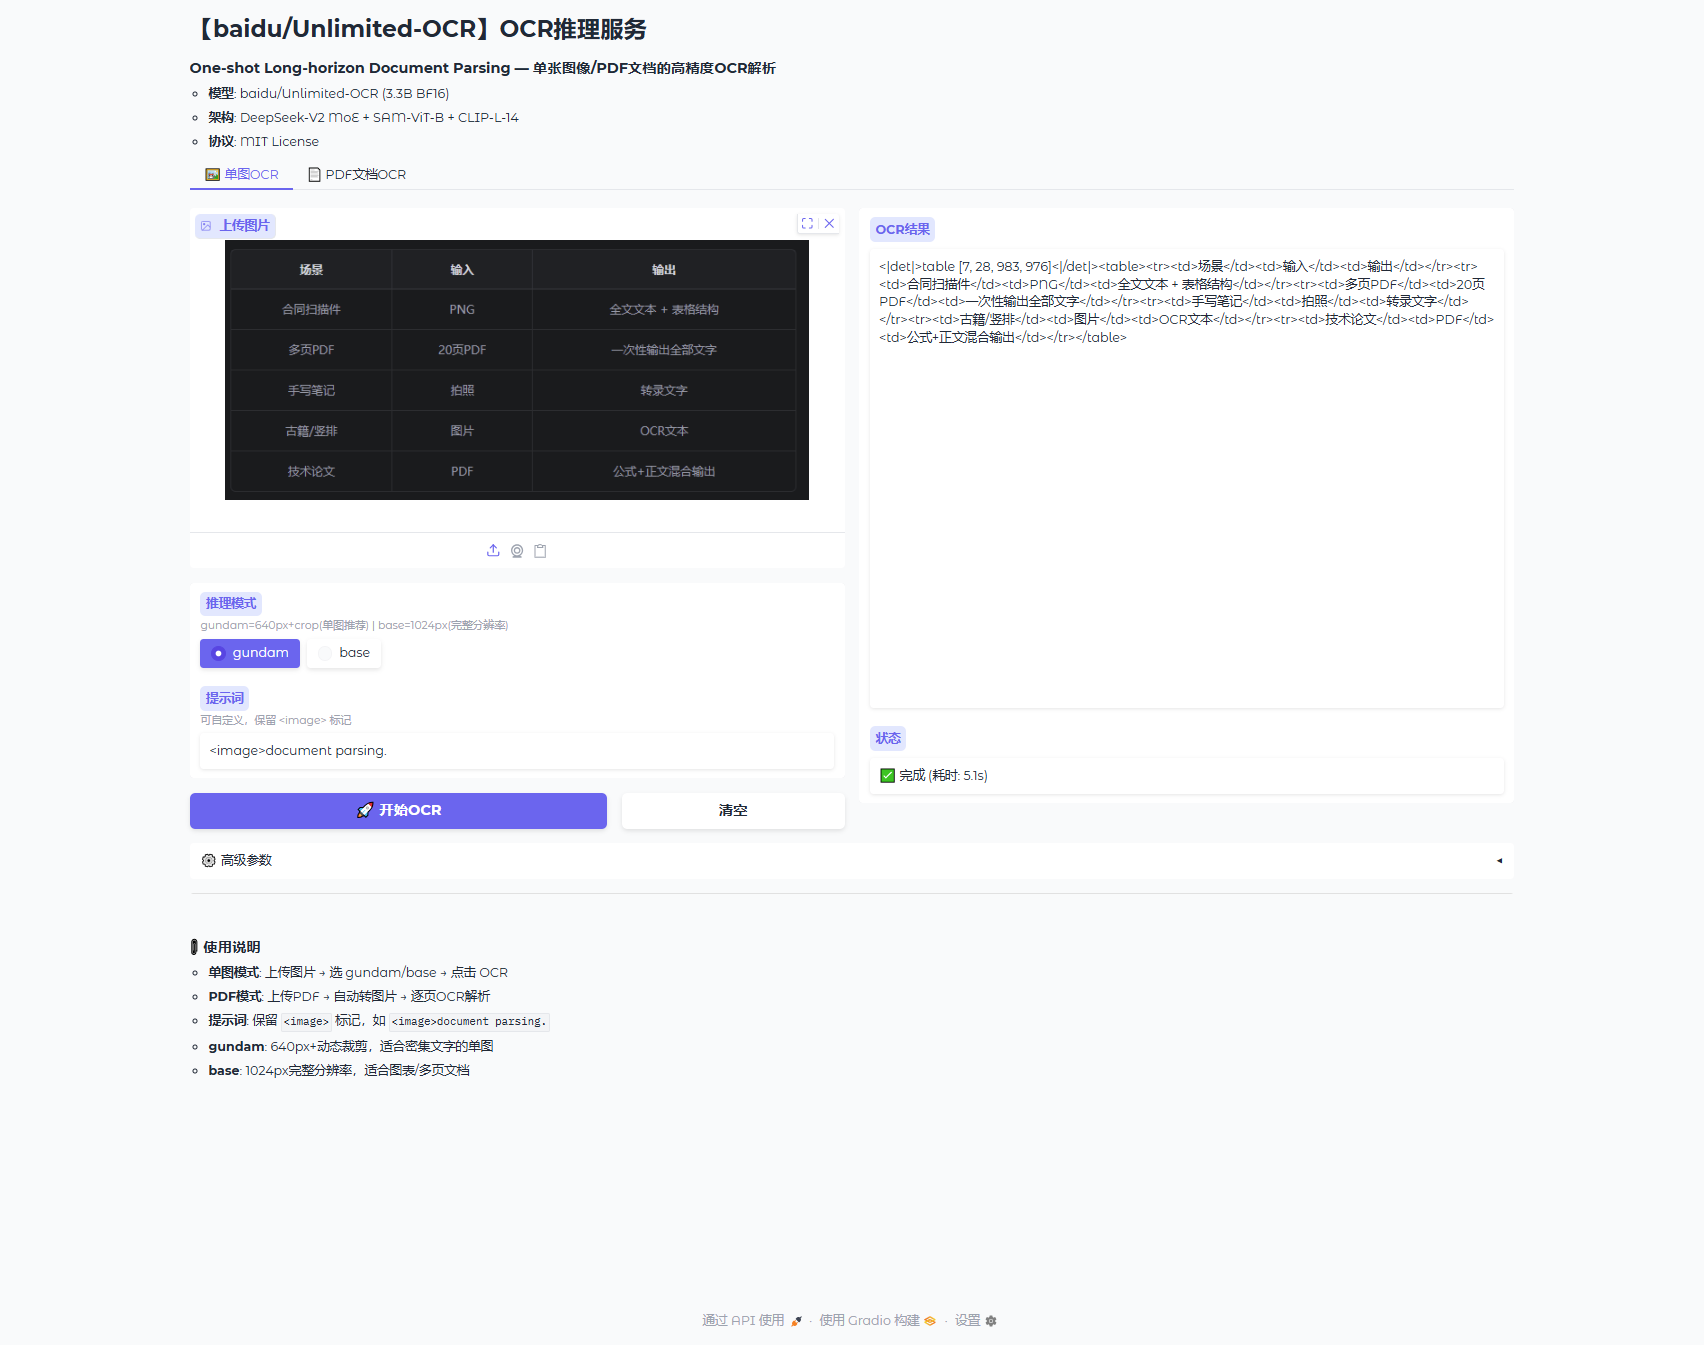

#### PDF OCR界面

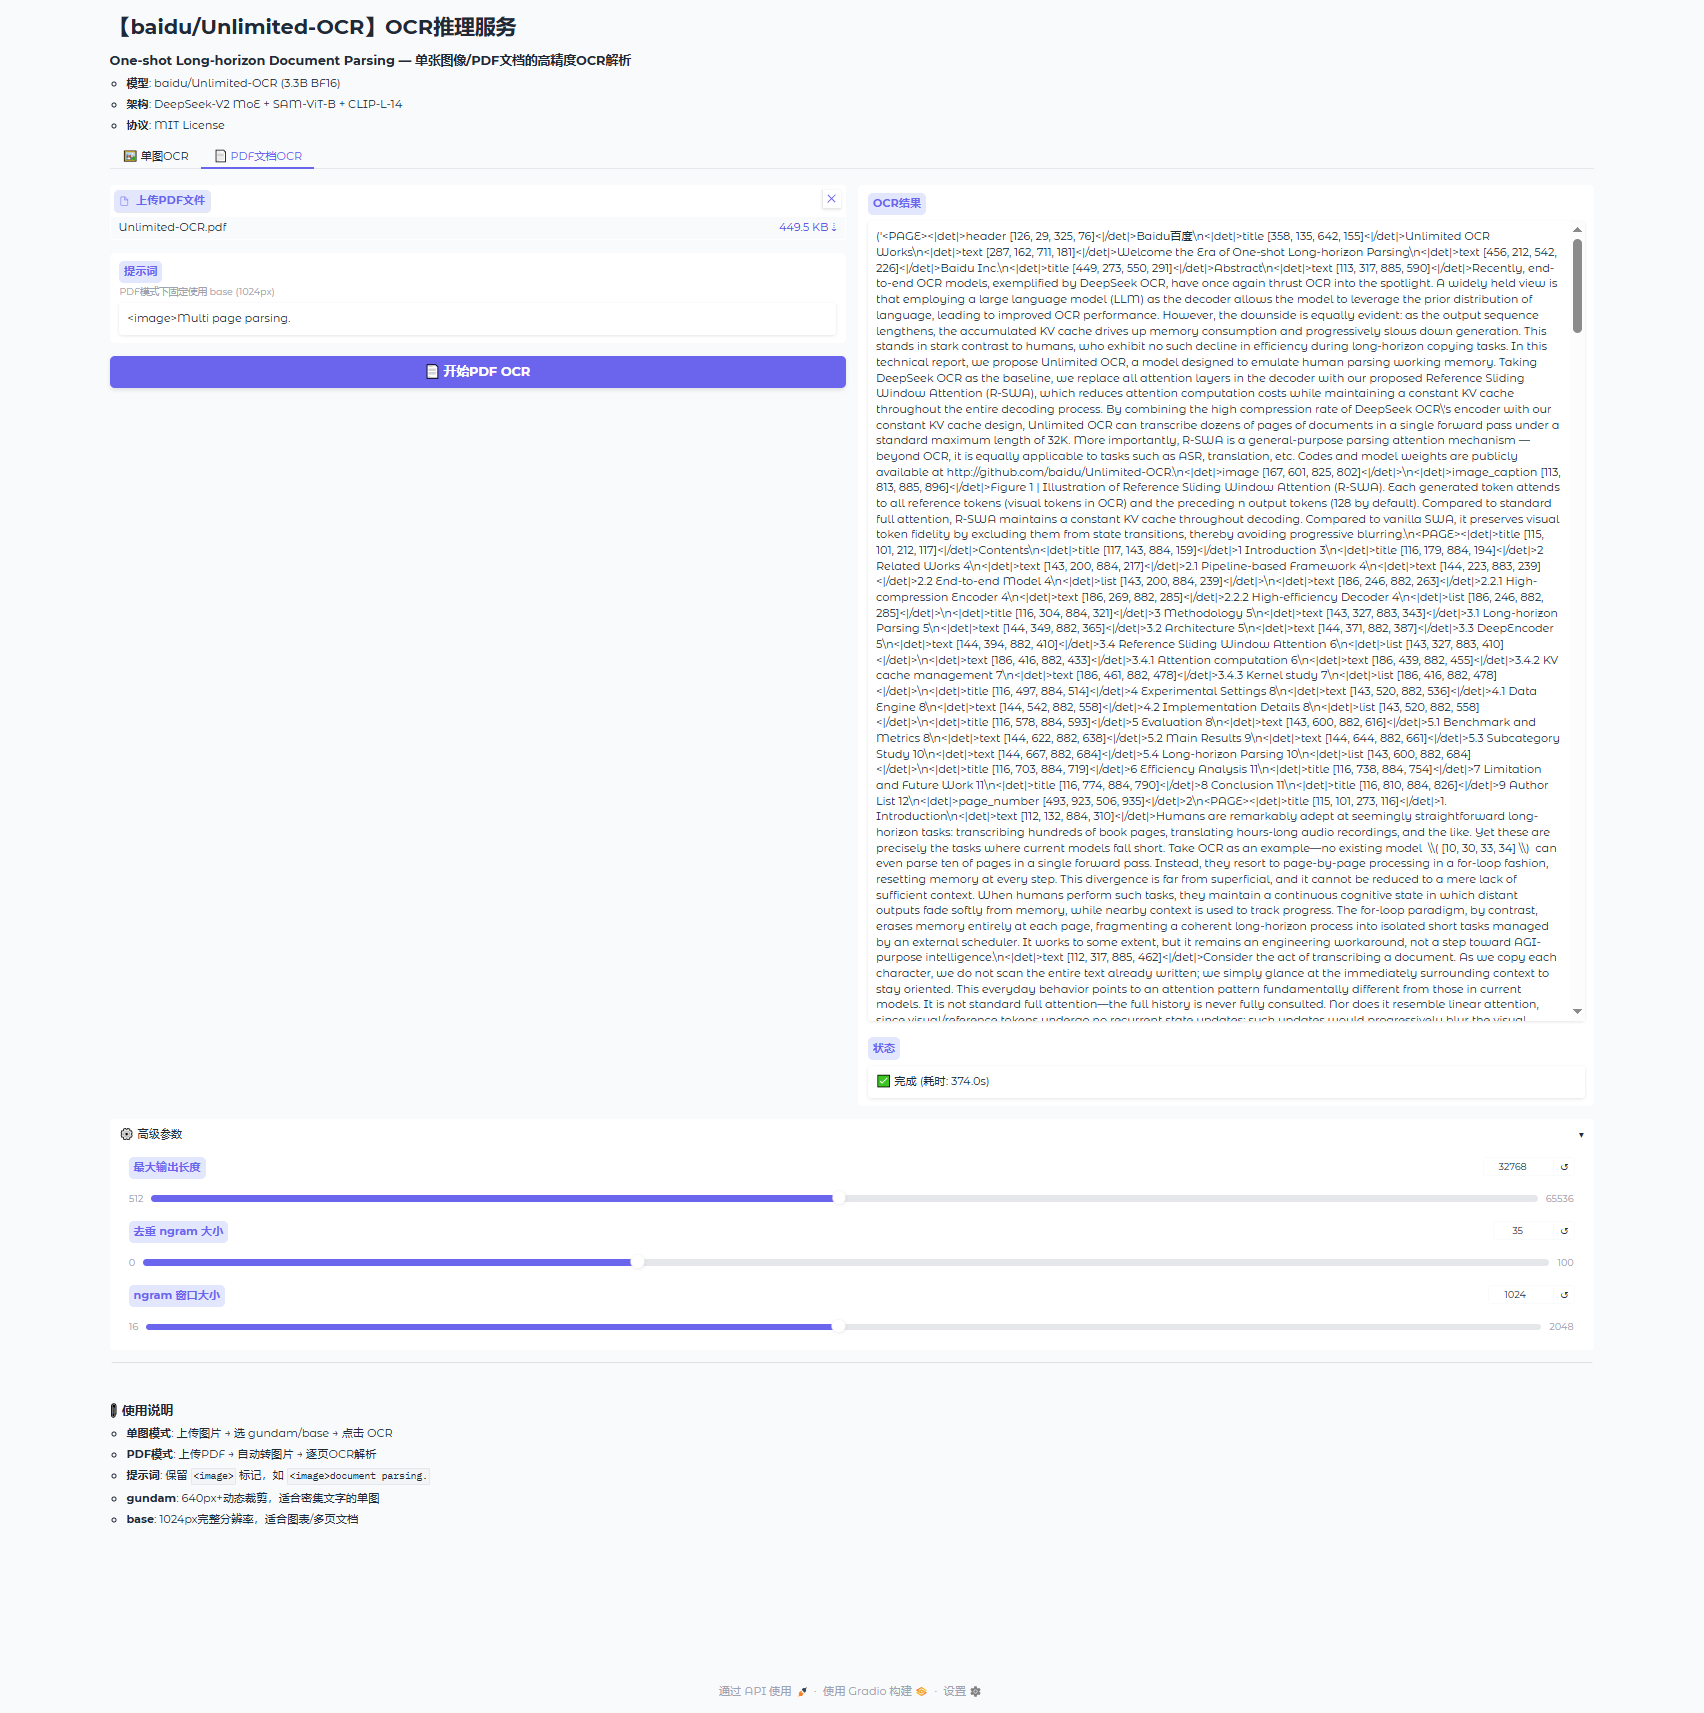


### 5.4 基准测试


In [ ]:
! cd /gemini/code && python benchmark_ocr.py


脚本会自动生成 `{模型名}_benchmark_result.json` 和 `{模型名}_benchmark_report.html`。

### 5.5 注意事项

1. **端口**：必须先开放 **7860** 端口
2. **模型加载时间**：首次约 12 分钟（~756s），可通过预热推理加快首次请求
3. **显存**：24GB 显存可流畅运行，gundam 模式显存占用更低
4. **PDF 模式**：固定使用 base（1024px），不支持 gundam 模式
5. **提示词**：必须保留 `<image>` 标记，否则模型无法识别输入
6. **输出格式**：输出为结构化格式，包含 `<|det|>` 检测框坐标和文字内容
7. **并发限制**：单卡推理，`default_concurrency_limit=1`，不支持并发请求
8. **批量 PDF**：每批最多处理 50 页，超长文档会自动分批处理
9. **Benchmark**：运行前需停掉 Gradio 服务（Ctrl+C）释放显存
10. **许可证**：MIT，可免费商用

## 六、模型评测结论

### 6.1 测试环境

| 项目 | 值 |
|------|------|
| GPU | S2.gpu.large（24GB） |
| 显存 | 24 GB（单卡） |
| 模型参数量 | 3.3B BF16 |
| 精度 | BF16 |
| 推理模式 | gundam（640px）/ base（1024px） |
| PyTorch | 2.10.0+cu124 |
| Transformers | 4.57.1 |
| 测试参数 | max_length=16384, no_repeat_ngram=35, 每场景 5 次 |

### 6.2 性能数据

| 场景 | 模式 | 图片尺寸 | TTFT平均(ms) | E2E平均(s) | 吞吐(char/s) | 输出chars |
|:----|:----:|:--------:|:---------:|:--------:|:----------:|:--------:|
| 短文本-小图 | gundam | 640×640px | 823.5 | 2.745 | 107.12 | 294 |
| 中文本-中图 | gundam | 640×640px | 2865.4 | 9.551 | 145.01 | 1385 |
| 长文本-大图 | base | 1024×1120px | 10868.3 | 36.228 | 142.00 | 5144 |
| 多页PDF（A4×3页） | base | A4 (595×842pt) | 10390.1 | 34.634 | 37.51 | 1299 |

### 6.3 核心结论

- **TTFT 性能**：gundam 模式小图 ~823ms，中图 ~2.9s；base 模式大图 ~10.9s
- **吞吐量**：gundam 模式中图最优 ~145 char/s，base 模式大图 ~142 char/s
- **PDF 处理**：3 页 A4 PDF 处理 ~34.6s，吞吐 ~37.5 char/s（需逐页转图推理）
- **延迟分布**：各场景成功率为 100%，P50 与平均接近，延迟稳定无异常抖动
- **模式对比**：gundam 模式 TTFT 更低（640px 分辨率），适合密集文字；base 模式分辨率更高，适合完整页面的精确检测
- **显存占用**：24GB 单卡足以运行所有场景

完整的性能评测数据详见测试报告目录。